In [9]:
# ── 환경 변수 로드 ──────────────────────────────────────────
# .env 파일에 저장된 API 키를 환경 변수로 불러옵니다.
from dotenv import load_dotenv

load_dotenv(r"C:\Users\pc\Desktop\src\.env")


True

In [10]:
# ── LangSmith 추적 설정 ──────────────────────────────────────
# 에이전트의 실행 흐름(어떤 코드를 생성하고 실행했는지)을 LangSmith에서 시각적으로 확인합니다.
# !pip install -qU langchain-teddynote
from langchain_teddynote import logging

logging.langsmith("CH15-Agent-CSV-Excel")


LangSmith 추적을 시작합니다.
[프로젝트명]
CH15-Agent-CSV-Excel


In [11]:
# ── 데이터 로드 ──────────────────────────────────────────────
# pandas로 CSV 파일을 DataFrame으로 불러옵니다.
# 에이전트는 이 df 객체를 직접 조작해서 분석 코드를 생성합니다.
# Excel 파일도 read_excel()로 동일하게 사용 가능합니다.
import pandas as pd

df = pd.read_csv("./data/titanic.csv")  # CSV 파일을 파싱합니다.
# df2 = pd.read_excel("./data/titanic.xlsx", sheet_name="Sheet1") # 엑셀 파일도 읽을 수 있습니다.
df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [12]:
!pip install langchain-experimental


In [13]:
# ── 콜백 함수 및 Python 실행 도구 설정 ──────────────────────
# PythonAstREPLTool: 에이전트가 생성한 Python 코드를 실제로 실행하는 도구입니다.
#   - AST(Abstract Syntax Tree) 기반으로 안전하게 코드를 파싱/실행합니다.
#   - locals["df"] = df: 에이전트가 생성한 코드 안에서 df 변수를 쓸 수 있게 주입합니다.
#
# 콜백 함수들:
#   - tool_callback: 에이전트가 코드를 실행할 때 어떤 코드인지 출력
#   - observation_callback: 코드 실행 결과(관찰값)를 출력
#   - result_callback: 최종 답변을 출력
from langchain_experimental.tools import PythonAstREPLTool

# 파이썬 코드를 실행하는 도구를 생성합니다.
python_tool = PythonAstREPLTool()
python_tool.locals["df"] = df  # df를 도구 실행 환경에 주입


# 도구 호출 시 실행되는 콜백 함수입니다.
def tool_callback(tool) -> None:
    print(f"<<<<<<< Code >>>>>>")
    if tool_name := tool.get("tool"):  # 도구에 입력된 값이 있다면
        if tool_name == "python_repl_ast":
            tool_input = tool.get("tool_input")
            for k, v in tool_input.items():
                if k == "query":
                    print(v)  # Query 를 출력합니다.
                    result = python_tool.invoke({"query": v})
                    print(result)
    print(f"<<<<<<< Code >>>>>>")


# 관찰 결과를 출력하는 콜백 함수입니다.
def observation_callback(observation) -> None:
    print(f"<<<<<<< Message >>>>>>")
    if "observation" in observation:
        print(observation["observation"])
    print(f"<<<<<<< Message >>>>>>")


# 최종 결과를 출력하는 콜백 함수입니다.
def result_callback(result: str) -> None:
    print(f"<<<<<<< 최종 대답 >>>>>>")
    print(result)
    print(f"<<<<<<< 최종 대답 >>>>>>")


In [14]:
import sys
print(sys.executable)


c:\Users\pc\miniconda3\python.exe


In [15]:
# ── Pandas DataFrame 에이전트 생성 ───────────────────────────
# create_pandas_dataframe_agent(): DataFrame을 직접 분석할 수 있는 에이전트를 생성합니다.
#
# [주요 파라미터]
#   - agent_type="tool-calling": LLM의 function calling 기능을 사용해 도구를 호출
#   - allow_dangerous_code=True: 에이전트가 임의의 Python 코드를 실행하도록 허용
#                                 (신뢰할 수 있는 환경에서만 사용)
#   - prefix: 에이전트에게 주는 역할 지침 (데이터 분석 전문가로 동작하도록 지시)
#             시각화는 seaborn 사용, plt.show() 필수 등 스타일 가이드 포함
#
# AgentCallbacks: tool/observation/result 각 단계에서 콜백 함수를 연결합니다.
# AgentStreamParser: 스트리밍 응답을 단계별로 파싱해 콜백을 호출합니다.
from langchain_experimental.agents.agent_toolkits import create_pandas_dataframe_agent
from langchain_openai import ChatOpenAI
from langchain_teddynote.messages import AgentStreamParser, AgentCallbacks

agent = create_pandas_dataframe_agent(
    ChatOpenAI(model="gpt-4o", temperature=0),
    df,
    verbose=False,
    agent_type="tool-calling",
    allow_dangerous_code=True,
    prefix="You are a professional data analyst and expert in Pandas. "
    "You must use Pandas DataFrame(`df`) to answer user's request. "
    "\n\n[IMPORTANT] DO NOT create or overwrite the `df` variable in your code. \n\n"
    "If you are willing to generate visualization code, please use `plt.show()` at the end of your code. "
    "I prefer seaborn code for visualization, but you can use matplotlib as well."
    "\n\n<Visualization Preference>\n"
    "- `muted` cmap, white background, and no grid for your visualization."
    "\nRecomment to set palette parameter for seaborn plot.",
)

parser_callback = AgentCallbacks(tool_callback, observation_callback, result_callback)
stream_parser = AgentStreamParser(parser_callback)


In [16]:
# ── 질문 헬퍼 함수 ────────────────────────────────────────────
# 매번 stream/parse 코드를 반복하지 않도록 ask()로 묶었습니다.
# 내부적으로 agent.stream() → stream_parser.process_agent_steps() 순서로 실행됩니다.
def ask(query):
    # 질문에 대한 대답을 출력합니다.
    response = agent.stream({"input": query})

    for step in response:
        stream_parser.process_agent_steps(step)


Failed to multipart ingest runs: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')


<<<<<<< Code >>>>>>
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate the correlation matrix
corr = df.corr()

# Set up the matplotlib figure
plt.figure(figsize=(10, 8))

# Draw the heatmap with the mask and correct aspect ratio
sns.heatmap(corr, cmap='muted', annot=True, fmt='.2f', square=True, linewidths=.5, cbar_kws={'shrink': .5}, 
            xticklabels=corr.columns, yticklabels=corr.columns)

plt.title('Correlation Heatmap')
plt.show()


Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')


ValueError: could not convert string to float: 'Braund, Mr. Owen Harris'
<<<<<<< Code >>>>>>
<<<<<<< Message >>>>>>
ValueError: could not convert string to float: 'Braund, Mr. Owen Harris'
<<<<<<< Message >>>>>>


Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')


<<<<<<< Code >>>>>>
# It seems like there was an error due to non-numeric columns. Let's select only numeric columns for correlation.

# Select only numeric columns
df_numeric = df.select_dtypes(include=['float64', 'int64'])

# Calculate the correlation matrix
corr = df_numeric.corr()

# Set up the matplotlib figure
plt.figure(figsize=(10, 8))

# Draw the heatmap with the mask and correct aspect ratio
sns.heatmap(corr, cmap='muted', annot=True, fmt='.2f', square=True, linewidths=.5, cbar_kws={'shrink': .5}, 
            xticklabels=corr.columns, yticklabels=corr.columns)

plt.title('Correlation Heatmap')
plt.show()
KeyError: "'muted' is not a known colormap name"
<<<<<<< Code >>>>>>
<<<<<<< Message >>>>>>
KeyError: "'muted' is not a known colormap name"
<<<<<<< Message >>>>>>


Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')


<Figure size 1000x800 with 0 Axes>

<Figure size 1000x800 with 0 Axes>

<<<<<<< Code >>>>>>
# Correct the colormap name and try again

# Set up the matplotlib figure
plt.figure(figsize=(10, 8))

# Draw the heatmap with the correct colormap
sns.heatmap(corr, cmap='coolwarm', annot=True, fmt='.2f', square=True, linewidths=.5, cbar_kws={'shrink': .5}, 
            xticklabels=corr.columns, yticklabels=corr.columns)

plt.title('Correlation Heatmap')
plt.show()


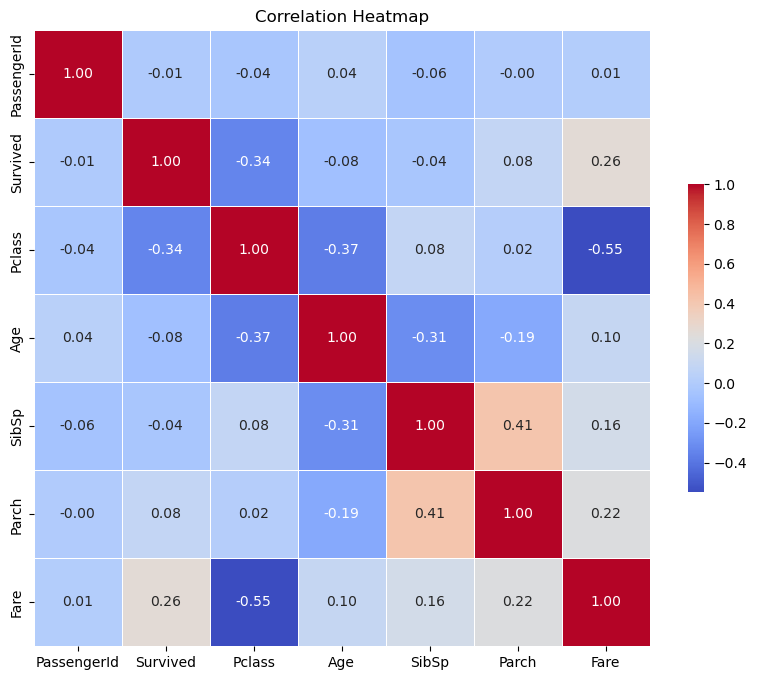

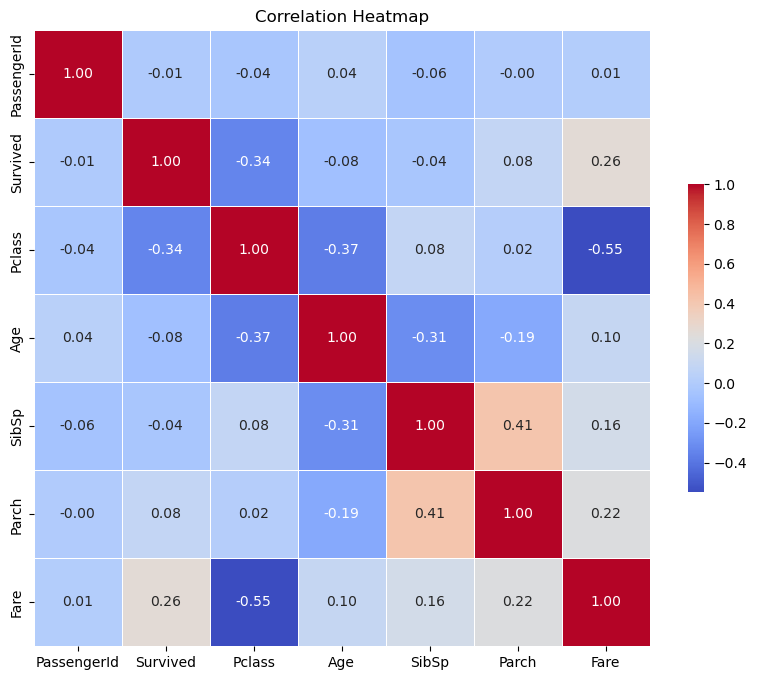


<<<<<<< Code >>>>>>
<<<<<<< Message >>>>>>

<<<<<<< Message >>>>>>


Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')


<<<<<<< 최종 대답 >>>>>>
I have generated a correlation heatmap using the numeric columns of the DataFrame. The heatmap visualizes the correlation between different features, with the color intensity representing the strength of the correlation.
<<<<<<< 최종 대답 >>>>>>


In [17]:
# ── 상관관계 히트맵 시각화 ────────────────────────────────────
# corr(): 수치형 컬럼 간의 상관계수(-1~1)를 계산합니다.
# 에이전트가 corr() 코드를 직접 생성하고 seaborn heatmap으로 시각화합니다.
response = agent.stream({"input": "corr() 을 사용해서 히트맵 시각화"})

for step in response:
    stream_parser.process_agent_steps(step)


In [18]:
# ── 데이터 기본 정보 확인 ─────────────────────────────────────
# 타이타닉 데이터셋의 컬럼 구성, 결측값, 데이터 타입 등 기본 정보를 물어봅니다.
ask("이 데이터 설명 해줘?")


Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')


<<<<<<< 최종 대답 >>>>>>
이 데이터는 타이타닉 호의 승객 정보를 담고 있는 데이터셋입니다. 각 행은 한 명의 승객을 나타내며, 열은 승객의 다양한 속성을 설명합니다. 각 열의 의미는 다음과 같습니다:

- `PassengerId`: 승객의 고유 식별자
- `Survived`: 생존 여부 (0 = 사망, 1 = 생존)
- `Pclass`: 티켓 클래스 (1 = 1등석, 2 = 2등석, 3 = 3등석)
- `Name`: 승객의 이름
- `Sex`: 성별
- `Age`: 나이
- `SibSp`: 함께 탑승한 형제자매 또는 배우자의 수
- `Parch`: 함께 탑승한 부모 또는 자녀의 수
- `Ticket`: 티켓 번호
- `Fare`: 운임 요금
- `Cabin`: 객실 번호
- `Embarked`: 탑승한 항구 (C = Cherbourg, Q = Queenstown, S = Southampton)

이 데이터셋은 타이타닉 생존자 분석에 자주 사용되며, 생존 여부와 관련된 다양한 요인을 분석하는 데 유용합니다.
<<<<<<< 최종 대답 >>>>>>


In [19]:
# ── 남녀 생존율 분석 ──────────────────────────────────────────
# 성별(Sex)에 따라 생존율(Survived)이 어떻게 다른지 분석합니다.
# 에이전트가 groupby + mean 코드를 생성해 계산하고 결과를 설명합니다.
ask("남자와 여자의 생존율에 차이는 뭐야?")


Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')


<<<<<<< Code >>>>>>
import pandas as pd

# Calculate survival rates by gender
gender_survival_rate = df.groupby('Sex')['Survived'].mean()
gender_survival_rate
Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64
<<<<<<< Code >>>>>>
<<<<<<< Message >>>>>>
Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64
<<<<<<< Message >>>>>>


Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')


<<<<<<< 최종 대답 >>>>>>
남자의 생존율은 약 18.89%이고, 여자의 생존율은 약 74.20%입니다. 여자의 생존율이 남자보다 훨씬 높습니다.
<<<<<<< 최종 대답 >>>>>>


Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')


<<<<<<< Code >>>>>>
import seaborn as sns
import matplotlib.pyplot as plt

# Set the style and palette
sns.set(style="white", palette="muted")

# Create a barplot for survival rate by Pclass
plt.figure(figsize=(10, 6))
sns.barplot(x='Pclass', y='Survived', data=df, ci=None)
plt.title('Survival Rate by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Survival Rate')
plt.show()


<string>:5: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.



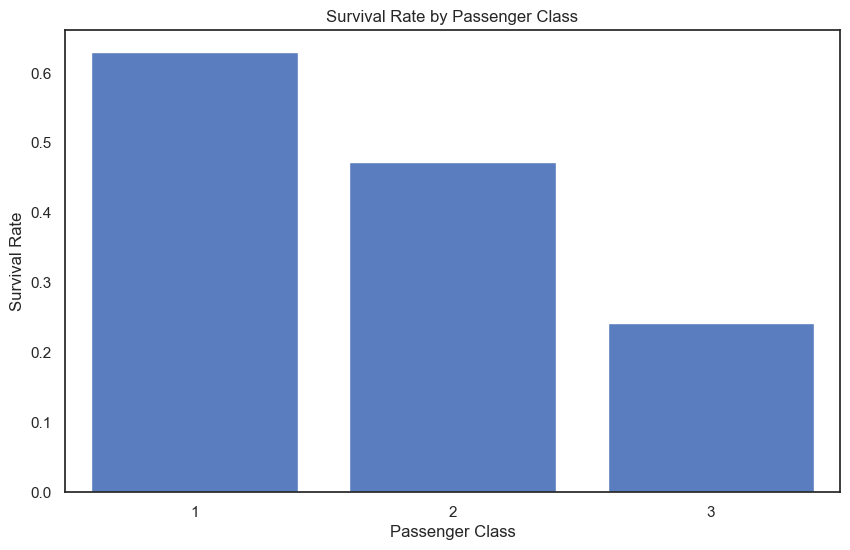


<<<<<<< Code >>>>>>


<string>:5: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.



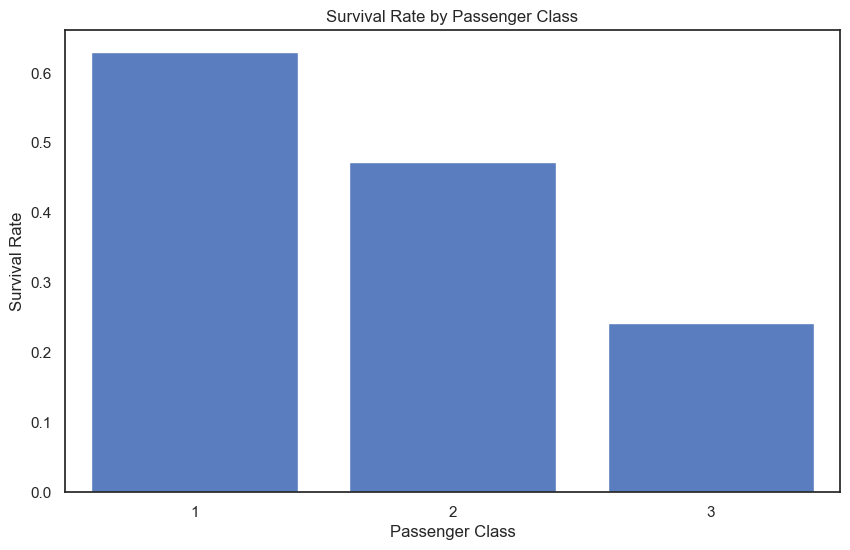

<<<<<<< Message >>>>>>

<<<<<<< Message >>>>>>


Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')


<<<<<<< 최종 대답 >>>>>>
위의 코드를 사용하여 객실 등급별 생존율을 시각화한 바플롯을 생성했습니다. 이 차트를 통해 각 객실 등급에 따른 생존율의 차이를 확인할 수 있습니다. 
<<<<<<< 최종 대답 >>>>>>


In [20]:
# ── 객실 등급별 생존율 시각화 ────────────────────────────────
# Pclass(1,2,3등석)별 생존율을 barplot으로 비교합니다.
# 에이전트가 seaborn barplot 코드를 자동 생성해 실행합니다.
ask("객실 등급별로 생존 등급별 생존하는데 차이는 차이야? 이걸 barplot 차트로 시각화 해줘")


Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')


<<<<<<< Code >>>>>>
# Filter the DataFrame for passengers in 1st and 2nd class with more than 10 people
filtered_df = df[df['Pclass'].isin([1, 2])]

# Check the number of passengers in each class
class_counts = filtered_df['Pclass'].value_counts()
class_counts
Pclass
1    216
2    184
Name: count, dtype: int64
<<<<<<< Code >>>>>>
<<<<<<< Message >>>>>>
Pclass
1    216
2    184
Name: count, dtype: int64
<<<<<<< Message >>>>>>


Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')


<<<<<<< Code >>>>>>
# Since both 1st and 2nd class have more than 10 passengers, we will extract detailed information for all passengers in these classes
filtered_df.head()
    PassengerId  Survived  Pclass  \
1             2         1       1   
3             4         1       1   
6             7         0       1   
9            10         1       2   
11           12         1       1   

                                                 Name     Sex   Age  SibSp  \
1   Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
3        Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
6                             McCarthy, Mr. Timothy J    male  54.0      0   
9                 Nasser, Mrs. Nicholas (Adele Achem)  female  14.0      1   
11                           Bonnell, Miss. Elizabeth  female  58.0      0   

    Parch    Ticket     Fare Cabin Embarked  
1       0  PC 17599  71.2833   C85        C  
3       0    113803  53.1000  C123        S

Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')


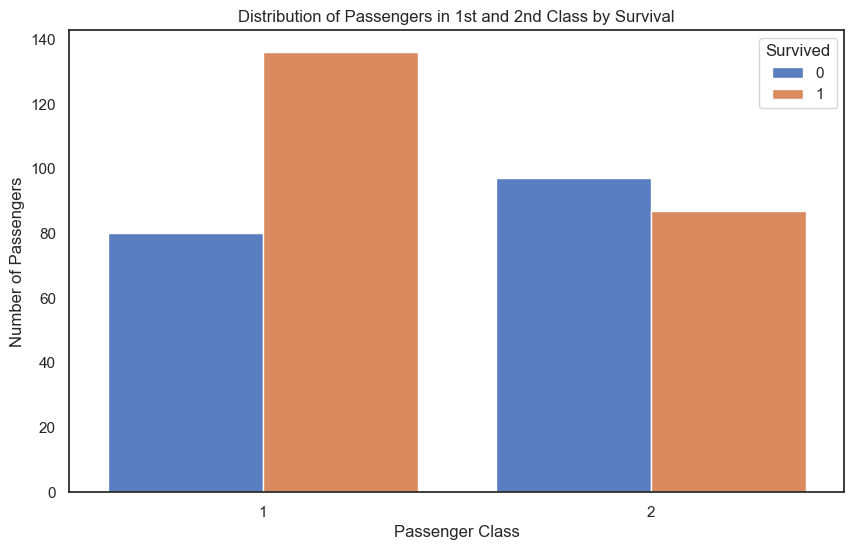

<<<<<<< Code >>>>>>
import seaborn as sns
import matplotlib.pyplot as plt

# Set the style and palette
sns.set(style="white", palette="muted")

# Plot the distribution of passengers in 1st and 2nd class
plt.figure(figsize=(10, 6))
sns.countplot(data=filtered_df, x='Pclass', hue='Survived')
plt.title('Distribution of Passengers in 1st and 2nd Class by Survival')
plt.xlabel('Passenger Class')
plt.ylabel('Number of Passengers')
plt.show()

<<<<<<< Code >>>>>>


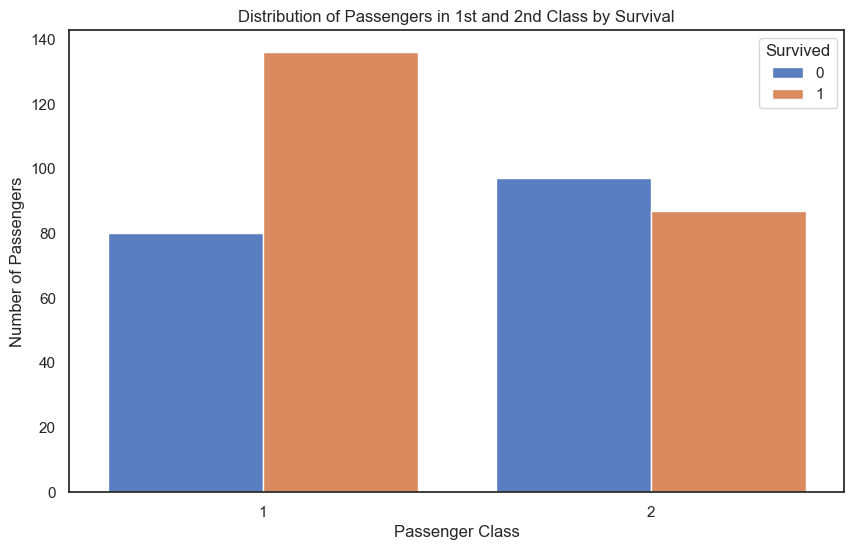

<<<<<<< Message >>>>>>

<<<<<<< Message >>>>>>


Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')


<<<<<<< 최종 대답 >>>>>>
I have extracted the detailed information for passengers in the 1st and 2nd classes, as both classes have more than 10 passengers. Additionally, I visualized the distribution of these passengers by class and survival status. The plot shows the number of passengers in each class who survived and those who did not.
<<<<<<< 최종 대답 >>>>>>


Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')


In [21]:
# ── 1,2등석 상위 10명 승객 분석 및 시각화 ────────────────────
# 1,2등석 승객 중 운임(Fare) 상위 10명을 필터링하고 시각화합니다.
# 복합 조건 필터링 + 정렬 + 시각화를 에이전트가 한 번에 처리합니다.
ask("1,2 등석에 탑승한 10명 이상의 어떤 사람이 탑승했는지 상세정보를 추출하고 시각화 하세요")
